In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [ ]:
def load_data():
  data = np.loadtxt("./data/houses.txt",delimiter=',')
  X = data[:,:4]
  y = data[:,4]
  return X, y


In [11]:
X_train , y_train = load_data()
X_features = ['size(sqft)','bedrooms','floors','age']


In [12]:
# implementing the normalization of data
scaler = StandardScaler() 
X_norm = scaler.fit_transform(X_train)
print(f"peak to peak range by column in X_norm:{np.ptp(X_norm,axis=0)}")
print(f"peak to peak range by column in X_train:{np.ptp(X_train,axis=0)}")


peak to peak range by column in X_norm:[5.8452591  6.13529646 2.05626214 3.68533012]
peak to peak range by column in X_train:[2.406e+03 4.000e+00 1.000e+00 9.500e+01]


In [15]:
# Creating and fitting of regression Model
# creating a model object 
sgdr = SGDRegressor(max_iter=1000)

# training the model 

sgdr.fit(X_norm,y_train)

print(sgdr.get_params()) 

print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")



{'alpha': 0.0001, 'average': False, 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.01, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'invscaling', 'loss': 'squared_error', 'max_iter': 1000, 'n_iter_no_change': 5, 'penalty': 'l2', 'power_t': 0.25, 'random_state': None, 'shuffle': True, 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
number of iterations completed: 126, number of weight updates: 12475.0


In [16]:
# Storing and view the paramss

b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
print( "model parameters from previous training: w: [110.56 -21.27 -32.71 -37.97], b: 363.16")


model parameters:                   w: [110.17762272 -21.08259262 -32.50271597 -38.01985386], b:[363.16434175]
model parameters from previous training: w: [110.56 -21.27 -32.71 -37.97], b: 363.16


In [17]:
# Making Predicitons

y_pred_sgdr = sgdr.predict(X_norm)


print(f"Prediction on training set:\n{y_pred_sgdr[:4]}" )
print(f"Target values \n{y_train[:4]}")

Prediction on training set:
[295.21587093 485.87497994 389.579432   492.03683804]
Target values 
[300.  509.8 394.  540. ]


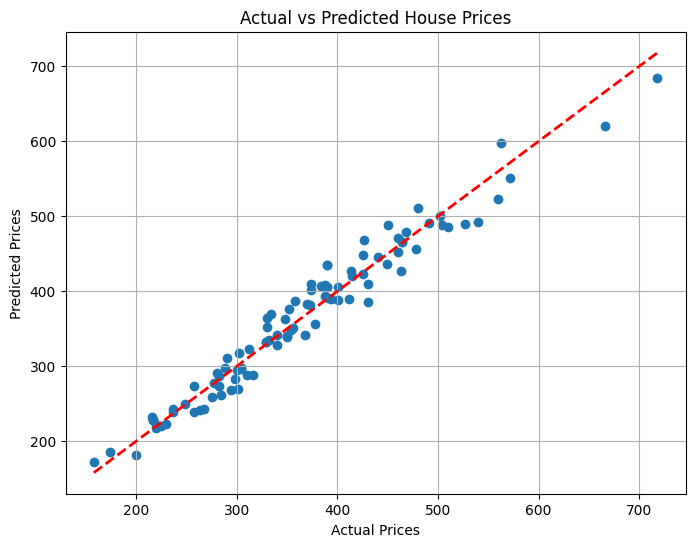

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_train, y_pred_sgdr)

# Perfect prediction line
min_val = min(y_train.min(), y_pred_sgdr.min())
max_val = max(y_train.max(), y_pred_sgdr.max())

plt.plot([min_val, max_val],[min_val, max_val],'r--',linewidth=2)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)

plt.show()